In [200]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [201]:
import sys; print(sys.version)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels as sms
%matplotlib inline
df = pd.read_csv("week-5-country-life-satisfaction.csv", index_col=0)
df.head()

3.9.25 (main, Dec 19 2025, 15:38:47) 
[GCC 8.5.0 20210514 (Red Hat 8.5.0-28.0.1)]


,Name,LifeSat,CountryCode,Region,HDI,LE,EYS,MYS,GNI
1,Afghanistan,3.794,AFG,South Asia,0.495960,64.486,10.138920,3.930000,1745.665705
2,Albania,4.644,ALB,Europe & Central Asia,0.791406,78.458,15.230000,10.054618,12299.799340
3,Algeria,5.872,DZA,Middle East & North Africa,0.758978,76.693,14.719379,7.986548,13639.434910
4,Angola,3.795,AGO,Sub-Saharan Africa,0.574488,60.782,11.777202,5.125460,5554.697384
5,Argentina,6.599,ARG,Latin America & Caribbean,0.830096,76.520,17.638360,10.564965,17611.218130


1. Exploring the data
(2 mark)
(a). Load the CSV into a DataFrame. Print its shape, the column data types, and the number of
missing values per column.

In [202]:
df = pd.read_csv('week-5-country-life-satisfaction.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(134, 10)
Unnamed: 0       int64
Name            object
LifeSat        float64
CountryCode     object
Region          object
HDI            float64
LE             float64
EYS            float64
MYS            float64
GNI            float64
dtype: object
Unnamed: 0     0
Name           0
LifeSat        0
CountryCode    0
Region         0
HDI            0
LE             0
EYS            0
MYS            0
GNI            0
dtype: int64


(b). Create a new column logGNI = log(GNI) using np.log. Plot histograms of GNI and logGNI side
by side and state in one sentence why the log transform is preferred as an indicator.

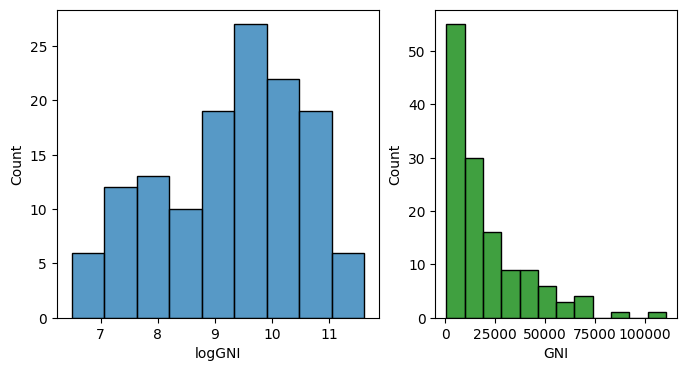

In [203]:
df["logGNI"] = np.log(df["GNI"])
df.head()

f, axs = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw=dict(width_ratios=[4,3]))
sns.histplot(data=df, x="logGNI", ax=axs[0], label="logGNI")
sns.histplot(data=df, x="GNI", ax=axs[1], color="g", label="GNI")
plt.show()

(c). Produce a pairwise plot (e.g. seaborn.pairplot) of LifeSat, LE, EYS, MYS and logGNI, and
print the correlation matrix of these five variables (rounded to 2 decimals).

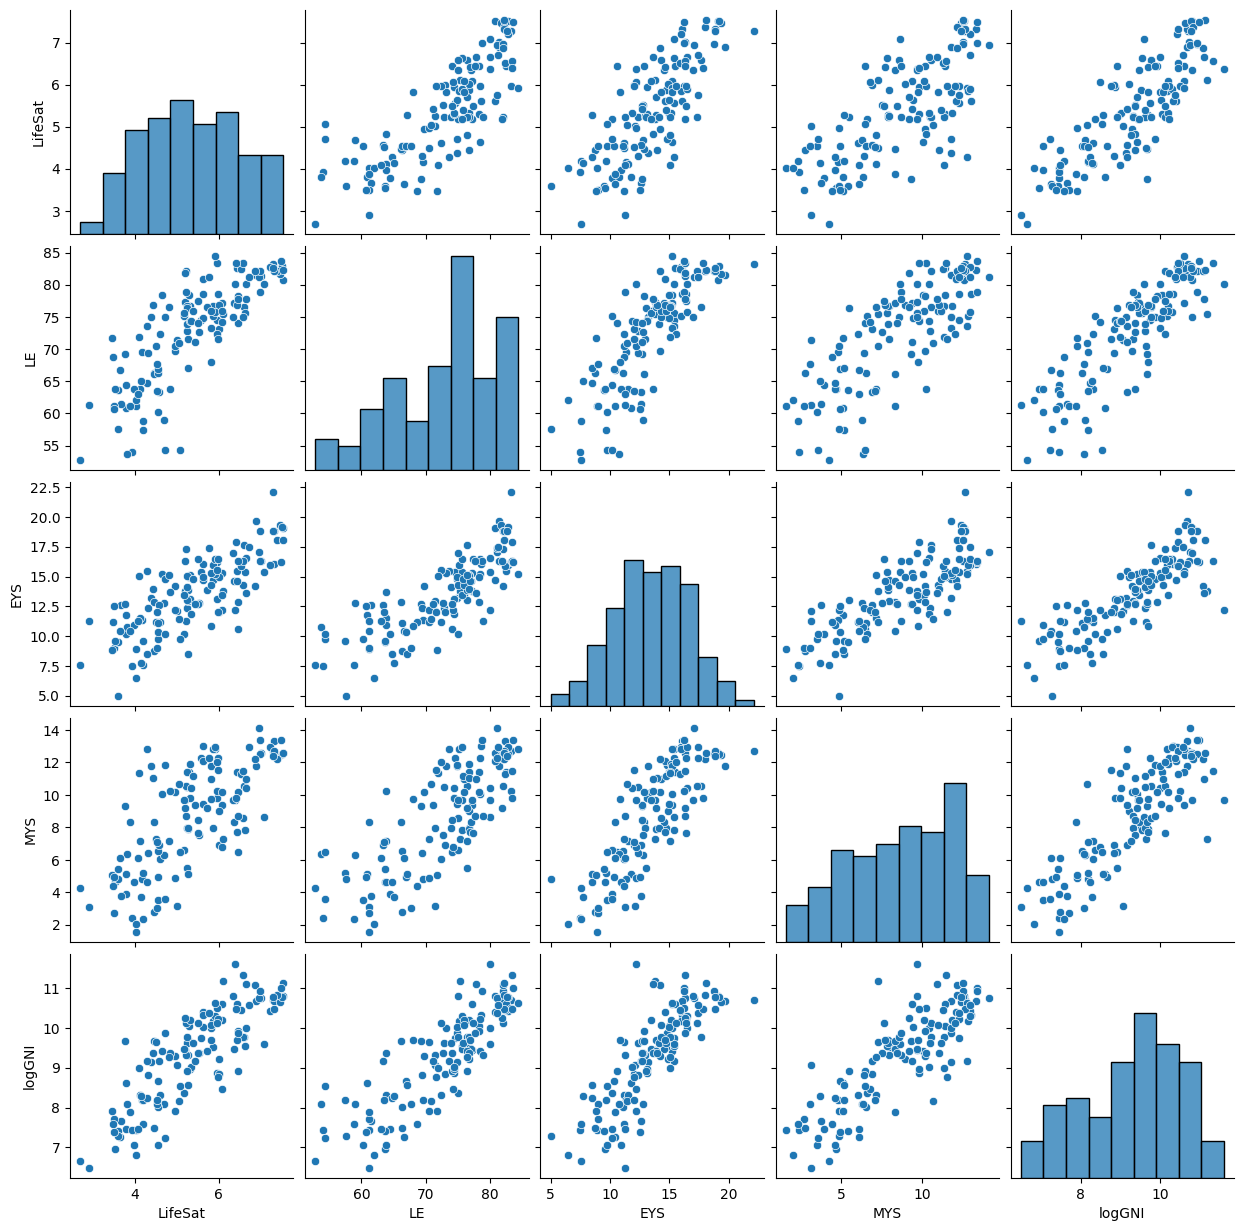

Correlation Matrix
         LifeSat    LE   EYS   MYS  logGNI
LifeSat     1.00  0.81  0.77  0.72    0.84
LE          0.81  1.00  0.81  0.78    0.86
EYS         0.77  0.81  1.00  0.82    0.83
MYS         0.72  0.78  0.82  1.00    0.84
logGNI      0.84  0.86  0.83  0.84    1.00


In [204]:
columns = ["LifeSat", "LE", "EYS", "MYS", "logGNI"]
sns.pairplot(data=df[columns])
plt.show()

print("Correlation Matrix")
print(round(df[columns].corr(), 2))

(d). Which indicator is most strongly correlated with LifeSat? Which pair of indicators is most
strongly correlated with each other?

The indicator most strongly correlated with LifeSat is logGNI. The pair of indicators most strongly correlated with each other is LE and logGNI, with a correlation of 0.86.

2. Fitting the model
(2 marks)
(a). Fit a linear regression predicting LifeSat from LE, EYS, MYS and logGNI. Print the full summary
(coefficients, standard errors, p-values, R^2 and adjusted R^2 ).

In [205]:
import statsmodels.api as sm

columns = ["LE", "EYS", "MYS", "logGNI"]
X = df[columns]
X = sm.add_constant(X)
y = df["LifeSat"]
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeSat   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     91.77
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.07e-37
Time:                        16:43:22   Log-Likelihood:                -120.17
No. Observations:                 134   AIC:                             250.3
Df Residuals:                     129   BIC:                             264.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9442      0.668     -4.405      0.0

(b). Write down the fitted regression equation with the estimated coefficients.

LifeSat = 0.0415 LE + 0.0654 EYS - 0.0290 MYS + 0.5017 logGNI - 2.9442

(c). Which indicators most strongly predict life satisfaction? Which ones are not statistically significant?

The most significant indicator is logGNI. The one least statistically significant is MYS.

(d). One coefficient has a sign that makes little substantive sense. Identify it and explain in 2–3
sentences how this can happen even though that indicator was positively correlated with LifeSat
in Q1.

MYS's coefficient has a negative sign, implying a negative correlation. This happens because we have multiple variables. If we keep all other variables constant, MYS would have a positive coefficient.

3. Comparing with an existing index
(2 marks)
(a). EYS and MYS are strongly correlated and largely measure the same concept. Drop the one whose
coefficient made less substantive sense in Q2, refit the regression . Call this reduced model
model2; use it for Questions 3 and 4.

In [206]:
columns2 = ["LE", "EYS", "logGNI"]
X = df[columns2]
X = sm.add_constant(X)
y = df["LifeSat"]
model2 = sm.OLS(y, X)
results2 = model2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeSat   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     122.3
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           1.10e-37
Time:                        16:43:22   Log-Likelihood:                -120.56
No. Observations:                 134   AIC:                             249.1
Df Residuals:                     130   BIC:                             260.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6394      0.570     -4.630      0.0

(b). The dataset contains HDI, which is built from these same indicators using a fixed formula. Compute the correlation between the fitted values of model2 and HDI.

In [207]:
print(f"Correlation: {results2.fittedvalues.corr(df['HDI'])}")

Correlation: 0.9890412322483967


(c). Compute the correlation between LifeSat and HDI.

In [208]:
print(f"Correlation: {df['LifeSat'].corr(df['HDI'])}")

Correlation: 0.8428343075288519


(d). Draw two scatter plots (fitted values vs. HDI; LifeSat vs. HDI)

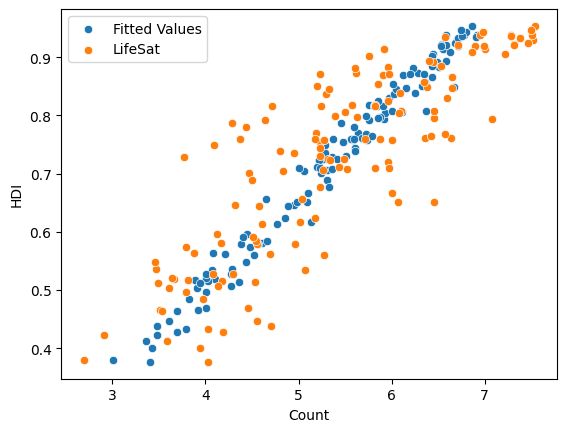

In [209]:
sns.scatterplot(x=results2.fittedvalues, y=df["HDI"], label="Fitted Values")
sns.scatterplot(x=df["LifeSat"], y=df["HDI"], label="LifeSat")
plt.xlabel("Count")
plt.ylabel("HDI")
plt.legend()
plt.show()

4. Looking at the residuals
(2 marks)
(a). Compute the residuals of model2 and identify the country with the largest positive residual
and the one with the largest negative residual.

In [210]:
resids = results2.resid
# print(df.to_string())
# print(resids.to_string())
print(f"Country with largest positive residual: {df['Name'].loc[resids.idxmax()]} ({resids.max()})")
print(f"Country with largest negative  residual: {df['Name'].loc[resids.idxmin()]} ({resids.min()})")

Country with largest positive residual: Guatemala (1.3679944873206944)
Country with largest negative  residual: Botswana (-1.5979177703886274)


(b). Print a table comparing these two countries on LifeSat, HDI, LE, EYS, MYS, GNI and Region.

In [211]:
# print(df[df["Name"].isin(['Guatemala', 'Botswana'])].set_index(["Name"]).T)
df[["Name", "LifeSat", "HDI", "LE", "EYS", "MYS", "GNI", "Region"]].iloc[[resids.idxmax(), resids.idxmin()]]

,Name,LifeSat,HDI,LE,EYS,MYS,GNI,Region
47,Guatemala,6.454,0.651035,74.063,10.621480,6.467886,7377.915813,Latin America & Caribbean
17,Botswana,3.766,0.727787,69.275,12.697235,9.330000,15951.330400,Sub-Saharan Africa


(c). Plot residuals against fitted values. Does the spread of the residuals look roughly constant?

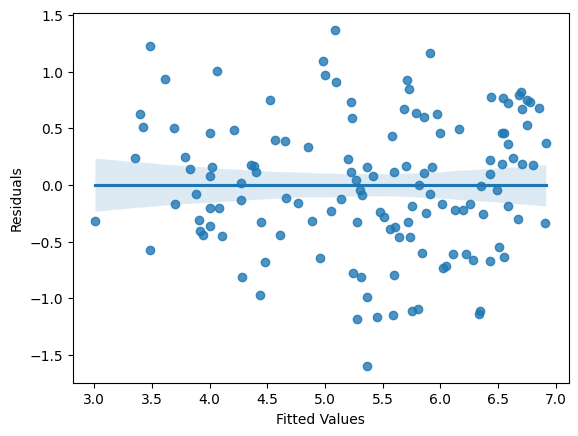

In [212]:
sns.regplot(x=results2.fittedvalues, y=results2.resid)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

No, the spread of the residuals does not look roughly constant.

5. Adding a categorical predictor
(2 marks)
(a). Add Region to model2 as a set of dummy variables, using either pd.get dummies with
drop first=True or a formula with C(Region). Print the summary.

In [213]:
model2 = smf.ols(formula="LifeSat ~ LE + EYS + logGNI + C(Region)", data = df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                LifeSat   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     49.89
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           4.84e-37
Time:                        16:43:23   Log-Likelihood:                -107.86
No. Observations:                 134   AIC:                             235.7
Df Residuals:                     124   BIC:                             264.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

(b). State which region is the baseline category and explain what a region coefficient means, holding
the other indicators constant.

In [214]:
print(df["Region"].unique())

['South Asia' 'Europe & Central Asia' 'Middle East & North Africa'
 'Sub-Saharan Africa' 'Latin America & Caribbean' 'East Asia & Pacific'
 'North America']


The region "East Asia & Pacific" is the baseline category. The region coefficient indicates the expected change in the dependent variable when moving from the baseline region to that region, keeping all other variables constant.

(c). Which regions report notably higher or lower life satisfaction than the baseline, and which of
these differences are statistically significant?

The regions reporting higher life satisfaction than the baseline are "North America" and "Latin America & Caribbean", as seen from their high region coefficients. The regions reporting lower life satisfaction than the baseline are "Europe & Central Asia" and "Middle East & North Africa" as seen from their low region coefficient. The differences for region "Latin America & Caribbean" is statistically significant, evidenced by its low p-value.

(d). Does adding Region improve the model? Compare R^2 and adjusted R^2 , and explain in one
sentence why adjusted R^2 is the fairer comparison here.

R^2 without Regions: 0.738
Adjusted R^2 without Regions: 0.732
R^2 with Regions: 0.784
Adjusted R^2 with Regions: 0.768
Adjusted R^2 is fairer because it penalizes the model for adding unnecessary predictors, unlike standard R^2 which automatically increases for every added variable.